In [2]:
import numpy as np
import matplotlib.pyplot as plt
import os
from tqdm import tqdm
import torch
import copy
from matplotlib.colors import hsv_to_rgb
import pandas as pd
import matplotlib as mpl
from matplotlib.widgets import LassoSelector
from matplotlib.path import Path
from sklearn.decomposition import PCA
from matplotlib.widgets import Slider

In [3]:
data = pd.read_csv("\\\\NAS_LOCCO\\Amaury\\DATA\\4_polar_MFM_these\\sperm_souris_0.csv", delimiter=';')
frame = data['frame']
x = data['x']
y = data['y']
z = data['z']
rho = data['rho']
eta = data['eta']
delta = data['delta']
N_photons = data['N_photon']
score = data['score']
x_start = data['x_start']
y_start = data['y_start']
z_start = data['z_start']
rho_start = data['rho_start']
delta_start = data['delta_start']

In [4]:
eta90 = copy.deepcopy(eta)
for ii in range(len(eta90)):
    if eta90[ii]>90:
        eta90[ii] = 180.-eta90[ii]

Text(0, 0.5, 'Occurences')

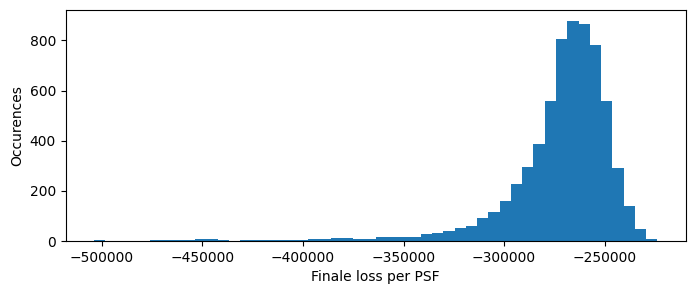

In [5]:
plt.rcParams['figure.figsize'] = [8,3]
hist = plt.hist(score, bins=50)
plt.xlabel('Finale loss per PSF')
plt.ylabel('Occurences')

Text(0, 0.5, 'Occurences')

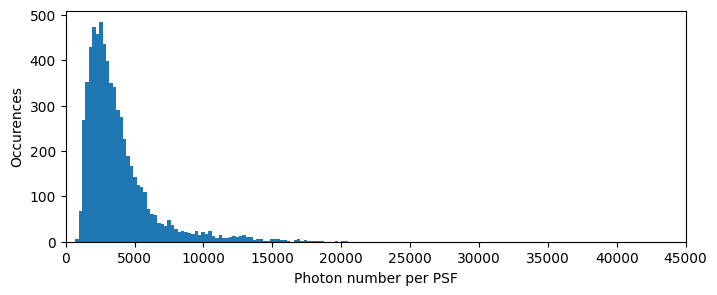

In [6]:
plt.rcParams['figure.figsize'] = [8,3]
hist = plt.hist(N_photons, bins=80)
plt.xlim((0, 45000))
plt.xlabel('Photon number per PSF')
plt.ylabel('Occurences')

Text(0, 0.5, 'Occurences')

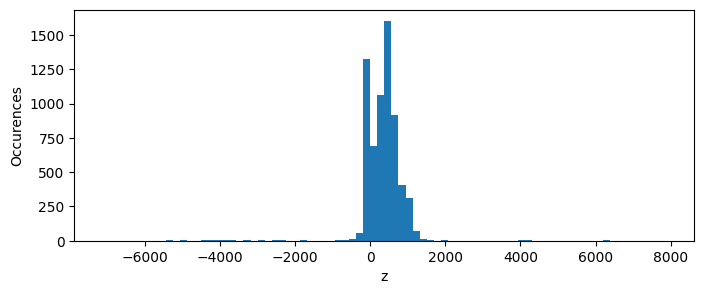

In [7]:
plt.rcParams['figure.figsize'] = [8,3]
hist = plt.hist(z, bins=80)
plt.xlabel('z')
plt.ylabel('Occurences')

In [17]:
loss_thresh = -22000
mask1 = (score<loss_thresh) & (delta<150) & (delta>30) & (N_photons>500) & (N_photons<15000) & (z<2000)  
zoom = (score<loss_thresh) & (delta<150) & (delta>30) & (N_photons>4000) & (N_photons<15000)  & (x<8000) & (y>-22000) & (y<-15000) & (z<900) 

threshold = (score<-430000) & (delta<150) & (x>17500) & (x<200000) & (y>2000) & (y<5500) & (z<1450) & (N_photons<85000) & (N_photons>6000) 
threshold2 = (score<-430000) & (delta<150) & (x>10000) & (x<22500) & (y>2000) & (y<15000) & (N_photons<85000) & (N_photons>6000) 
threshold3 = (score<-430000) & (delta<150) & (x>10000) & (x<22500) & (y>2000) & (y<15000) & (z<1450) & (N_photons<85000) & (N_photons>6000) 
threshold4 = (score<-430000) & (N_photons<85000) & (N_photons>6000) 

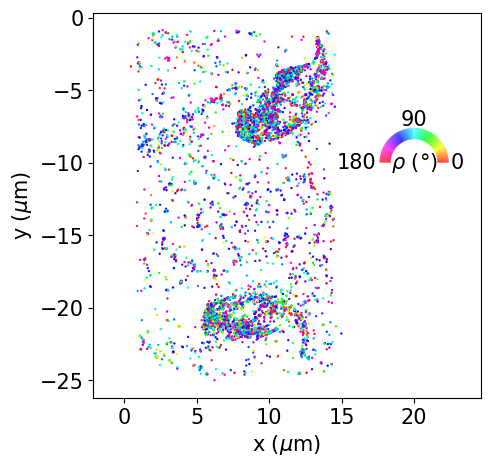

In [18]:
%matplotlib inline
plt.rcParams['figure.figsize'] = [5, 5]
plt.rcParams.update({'font.size': 15})
hues = rho[mask1] / 180.0
hsv_colors = np.stack((hues, np.ones_like(hues), np.ones_like(hues)), axis=1)
rgb_colors = hsv_to_rgb(hsv_colors)
plt.scatter(x[mask1]/1000, y[mask1]/1000, c=rgb_colors, s=0.5)
plt.axis('equal')
#plt.xlim((10000, 22500))
#plt.ylim((2200, 14000))
plt.xlabel('x ($\\mu$m)')
plt.ylabel('y ($\\mu$m)')

# Half-circle colorbar rotated 90° clockwise
center_x, center_y = 20, -10
radius = 2
angles = np.linspace(0, np.pi, 200)  # rotated arc
for i in range(len(angles)-1):
    theta1, theta2 = angles[i], angles[i+1]
    hue = (np.degrees(theta1)) / 180.0  # Map to 0-1 range
    color = hsv_to_rgb([hue, 1, 1])
    arc_x = [center_x + radius * np.cos(theta1), center_x + radius * np.cos(theta2)]
    arc_y = [center_y + radius * np.sin(theta1), center_y + radius * np.sin(theta2)]
    plt.plot(arc_x, arc_y, color=color, lw=8, solid_capstyle='butt')

# Tick labels with offset
tick_angles = [180, 90, 0]  # Corresponding to hue range
label_offset = [-6.,1, -5]
plt.text(center_x, center_y, "$\\rho$ ($\\degree$)", ha='center', va='center', fontsize=15)
for i, ang in enumerate(tick_angles):
    rad = np.radians(ang)
    tx = center_x + (radius + label_offset[i]) * np.cos(np.pi-rad)
    ty = center_y + (radius + label_offset[i]) * np.sin(np.pi-rad)
    plt.text(tx, ty, f"{(ang)}", ha='center', va='center', fontsize=15)
#plt.xlim((6, 13.5))
#plt.ylim((12.8, 18.5))
#plt.savefig("imE.png", format="png")
plt.show()

6549


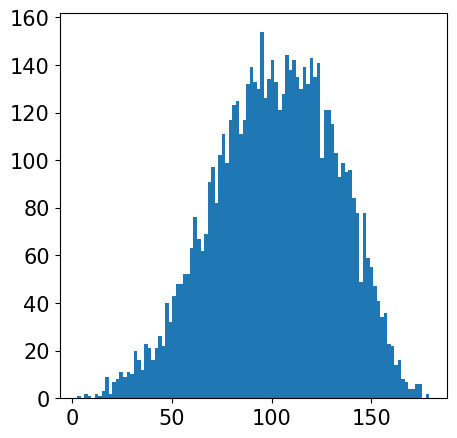

In [19]:
hh = plt.hist(delta, bins=100)
print(len(delta))

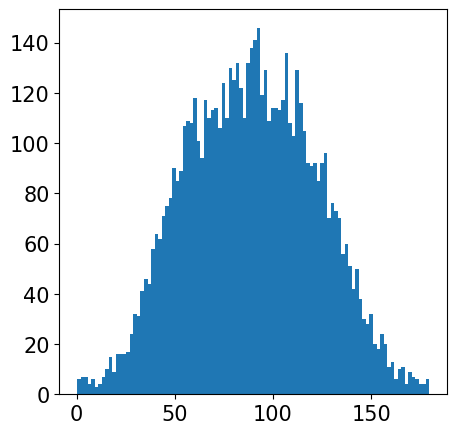

In [20]:
hh = plt.hist(eta, bins=100)

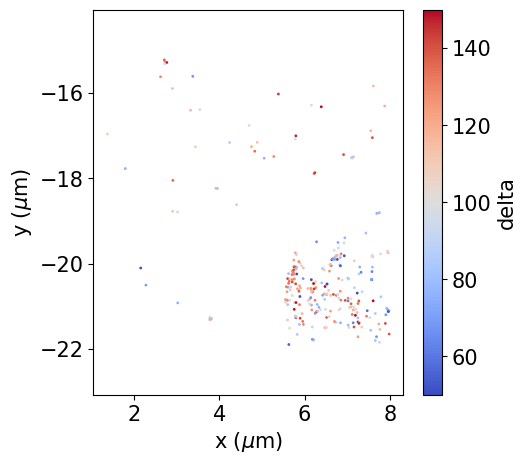

In [21]:
vals = delta[zoom]

norm = mpl.colors.Normalize(vmin=50., vmax=150.)

sc = plt.scatter(
    x[zoom]/1000,
    y[zoom]/1000,
    c=vals,
    s=1,
    cmap='coolwarm',
    norm=norm
)

plt.axis('equal')
plt.xlabel('x ($\\mu$m)')
plt.ylabel('y ($\\mu$m)')

cbar = plt.colorbar(sc)
cbar.set_label('delta')

plt.show()

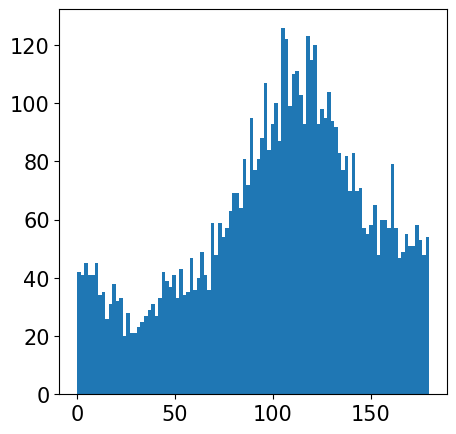

In [22]:
hh = plt.hist(rho[mask1], bins=100)

# Select ROI rho

In [44]:
%matplotlib qt
plt.rcParams['figure.figsize'] = [15,15]
fig = plt.figure()
ax = fig.add_subplot()
norm = mpl.colors.Normalize(vmin=0., vmax=180.)
vals = rho[mask1]
sc = ax.scatter(x[mask1] , y[mask1], c=vals , cmap='hsv', norm=norm, s=5)
ax.axis('equal')
cb = plt.colorbar(sc)
cb.ax.invert_yaxis()
points = np.column_stack((x, y))
mask = np.zeros(len(x), dtype=bool)

def onselect(verts):
    global mask
    path = Path(verts)
    mask = path.contains_points(points)
    print(mask)

lasso = LassoSelector(ax, onselect)
plt.show()

[False False False ... False False False]


In [46]:
angles = np.deg2rad(rho[mask])
bins = 18
counts, bin_edges = np.histogram(angles, bins=bins, density=True)

bin_centers = (bin_edges[:-1] + bin_edges[1:]) / 2
width = bin_edges[1] - bin_edges[0]

# Duplicate with π shift
bin_centers_full = np.concatenate([bin_centers, bin_centers + np.pi])
counts_full = np.concatenate([counts, counts])

# ----- Figure layout -----
fig = plt.figure(figsize=(10, 5))

# Polar subplot
ax1 = fig.add_subplot(1, 2, 1, projection='polar')

ax1.bar(bin_centers_full, counts_full, width=width, alpha=0.8)

ax1.set_theta_zero_location("N")
ax1.set_theta_direction(-1)
ax1.set_yticklabels([])

# PCA
XY = np.column_stack((x[mask], y[mask]))
pca = PCA(n_components=1)
principal_coord = pca.fit_transform(XY).flatten()

# Sort along principal axis
idx = np.argsort(principal_coord)
x_sorted = principal_coord[idx]
z_sorted = z[mask].values[idx]   # use .values if it's pandas

# Moving average window size (adjust!)
window = 150

z_smooth = np.convolve(
    z_sorted,
    np.ones(window)/window,
    mode='valid'
)

# Correct matching x values
x_smooth = x_sorted[:len(z_smooth)]

# Cartesian subplot
ax2 = fig.add_subplot(1, 2, 2)
ax2.plot(x_smooth, z_smooth, color='red', linewidth=2)
ax2.scatter(principal_coord, z[mask], s=5, alpha=0.6)

ax2.set_xlabel("lateral coordinate")
ax2.set_ylabel("z")
ax2.set_aspect('equal')
ax2.set_title("lat–z scatter")
ax2.grid()
ax2.set_ylim(0,800)
plt.tight_layout()
plt.show()

ValueError: x and y must have same first dimension, but have shapes (69,) and (82,)

# select  ROI eta

In [43]:
%matplotlib qt
plt.rcParams['figure.figsize'] = [15,15]
fig = plt.figure()
ax = fig.add_subplot()
norm = mpl.colors.Normalize(vmin=20., vmax=160.)
vals = eta[mask1]
sc = ax.scatter(x[mask1] , y[mask1], c=vals , cmap='coolwarm', norm=norm, s=1)
ax.axis('equal')
cb = plt.colorbar(sc)
cb.ax.invert_yaxis()
points = np.column_stack((x, y))
mask = np.zeros(len(x), dtype=bool)

def onselect(verts):
    global mask
    path = Path(verts)
    mask = path.contains_points(points)
    print(mask)

lasso = LassoSelector(ax, onselect)
plt.show()

## 3D plot of the ROI

In [26]:
%matplotlib qt
plt.rcParams['figure.figsize'] = [15,15]
fig = plt.figure()
ax = fig.add_subplot(projection='3d')
norm = mpl.colors.Normalize(vmin=0., vmax=180.)
vals = eta[mask]
sc = ax.scatter(x[mask] , y[mask], z[mask], c=vals , cmap='coolwarm', norm=norm, s=1)
ax.axis('equal')
cb = plt.colorbar(sc)

## eta anlysis

In [24]:
angles = np.deg2rad(eta[mask])
bins = 18
counts, bin_edges = np.histogram(angles, bins=bins, density=True)

bin_centers = (bin_edges[:-1] + bin_edges[1:]) / 2
width = bin_edges[1] - bin_edges[0]

# Duplicate with π shift
bin_centers_full = np.concatenate([bin_centers, bin_centers + np.pi])
counts_full = np.concatenate([counts, counts])

# ----- Figure layout -----
fig = plt.figure(figsize=(10, 5))

# Polar subplot
ax1 = fig.add_subplot(1, 2, 1, projection='polar')

ax1.bar(bin_centers_full, counts_full, width=width, alpha=0.8)

ax1.set_theta_zero_location("N")
ax1.set_theta_direction(-1)
ax1.set_yticklabels([])

# PCA
XY = np.column_stack((x[mask], y[mask]))
pca = PCA(n_components=1)
principal_coord = pca.fit_transform(XY).flatten()

# Sort along principal axis
idx = np.argsort(principal_coord)
x_sorted = principal_coord[idx]
z_sorted = z[mask].values[idx]   # use .values if it's pandas

# Moving average window size (adjust!)
window = 150

z_smooth = np.convolve(
    z_sorted,
    np.ones(window)/window,
    mode='valid'
)

# Correct matching x values
x_smooth = x_sorted[:len(z_smooth)]

# Cartesian subplot
ax2 = fig.add_subplot(1, 2, 2)
ax2.plot(x_smooth, z_smooth, color='red', linewidth=2)
ax2.scatter(principal_coord, z[mask], s=5, alpha=0.6)

ax2.set_xlabel("lateral coordinate")
ax2.set_ylabel("z")
ax2.set_aspect('equal')
ax2.set_title("lat–z scatter")
ax2.grid()
ax2.set_ylim(0,800)
plt.tight_layout()
plt.show()

[False False False ... False False False]


# Sliding window

In [87]:
angle_to_analyse=eta

In [94]:
%matplotlib qt
plt.rcParams['figure.figsize'] = [15, 15]

# Example: angle array in degrees (replace with yours)
theta = angle_to_analyse[mask1]   # or use your own angle array

window_width = 10.0  # degrees
half_width = window_width / 2

fig, ax = plt.subplots()
plt.subplots_adjust(bottom=0.15)

norm = mpl.colors.Normalize(vmin=0., vmax=180.)
vals = angle_to_analyse

# Initial center
theta0 = 0.0

# Initial mask
def compute_mask(center):
    diff = (theta - center + 180) % 360 - 180
    return (np.abs(diff) <= half_width)&mask1

mask2 = compute_mask(theta0)

# Initial scatter
sc = ax.scatter(
    x[mask2],
    y[mask2],
    c=vals[mask2],
    cmap='coolwarm',
    norm=norm,
    s=1
)

ax.axis('equal')
cb = plt.colorbar(sc)
cb.ax.invert_yaxis()

# Slider axis
ax_slider = plt.axes([0.2, 0.05, 0.6, 0.03])
slider = Slider(
    ax=ax_slider,
    label='Angle center (deg)',
    valmin=half_width,
    valmax=180-half_width,
    valinit=theta0
)

# Update function
def update(val):
    center = slider.val
    mask2 = compute_mask(center)

    # Update scatter points
    sc.set_offsets(np.column_stack((x[mask2], y[mask2])))
    sc.set_array(vals[mask2])

    fig.canvas.draw_idle()

slider.on_changed(update)

plt.show()